In [1]:
pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 6.9 MB/s eta 0:00:00


In [2]:
pip install pymongo pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 7.8 MB/s eta 0:00:00


In [3]:
pip install pymongo certifi

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
import certifi
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from hmmlearn.vhmm import VariationalGaussianHMM
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, precision_score, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler, FunctionTransformer, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Query the data

In [5]:
# @title
def query_mongodb(uri="blured", collection_name="vix_data", db_name="DB_VIX", filtro=None):
    client = MongoClient(uri, tls=True, tlsCAFile=certifi.where())

    db = client[db_name]
    collection = db[collection_name]

    filtro = filtro or {}

    # bring data
    docs = list(collection.find(filtro))

    if not docs:
        return pd.DataFrame()

    df = pd.DataFrame(docs)

    # transform _id to datetime
    if "_id" in df.columns:
        df["_id"] = pd.to_datetime(df["_id"])
        df.set_index("_id", inplace=True)

    return df

In [6]:
data =query_mongodb()
data.tail()

,DXY_overnight,Drawdown,GOLD_overnight,IV_RV_Ratio,Intraday_VIX_Move,Momentum_1M,Momentum_3M,Momentum_6M,OIL_overnight,Open_DXY,...,VIX_Percentile,VIX_RV_Spread,VIX_STD_10,VIX_STD_5,VIX_Trend,VIX_Vol_10d,VIX_Vol_21d,VIX_Vol_5d,VIX_Zscore,VIX_Zscore_Sq
_id,,,,,,,,,,,,,,,,,,,,,
2026-03-24,0.001920,-0.056974,-0.014850,188.128728,1,-0.047545,-0.050642,-0.009438,0.007375,99.139999,...,0.920635,26.010999,1.663384,1.749214,3.082028,0.086527,0.101414,0.085438,0.808669,0.653946
2026-03-25,-0.002313,-0.060504,0.034028,198.173289,0,-0.041151,-0.054195,-0.015739,-0.041798,99.199997,...,0.936508,26.814009,1.752610,1.218290,3.178371,0.086229,0.099766,0.075311,0.968122,0.937260
2026-03-26,0.000301,-0.055412,-0.023803,188.732129,1,-0.043275,-0.048780,-0.014437,0.011736,99.629997,...,0.916667,25.195789,1.707609,1.187363,3.157541,0.088415,0.099382,0.069815,0.356721,0.127250
2026-03-27,-0.000300,-0.071854,-0.000846,197.660900,1,-0.067515,-0.062061,-0.034873,-0.012384,99.870003,...,0.952381,27.301177,1.725914,0.814156,3.256107,0.082894,0.097634,0.071963,1.084801,1.176793
2026-03-30,0.003475,-0.087374,0.006233,212.181445,0,-0.078162,-0.076475,-0.051598,0.099561,100.217003,...,0.984127,30.903662,2.435063,2.200722,3.549031,0.092090,0.100354,0.077641,2.258059,5.098832


In [7]:
data["Intraday_VIX_Move"]. value_counts()

,count
Intraday_VIX_Move,
1,1705
2,1623
0,1621


## Walk-forward expanding window

In [8]:
# 1. Clean and Scale
def clean_features(X):
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.ffill().fillna(0)
    return X.astype(np.float64)

# 1.1 PCA
def build_pipeline_pca(n_components=14):
    return Pipeline([
        ("clean", FunctionTransformer(clean_features)),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components))
    ])

# 2. Walk_forward function
def walk_forward_expanding(data, initial_years=15, daily_window=500, n_components=14):

    X = data.drop(columns=["Intraday_VIX_Move"]).copy()
    y = data["Intraday_VIX_Move"].copy()

    all_splits = []
    initial_window = initial_years * 252

    #  INITIAL split
    X_train_init = X.iloc[:initial_window]
    y_train_init = y.iloc[:initial_window]

    pipeline_init = build_pipeline_pca(n_components)

    X_init_transformed = pipeline_init.fit_transform(X_train_init)
    n_comp_init = X_init_transformed.shape[1]

    X_train_init_scaled = pd.DataFrame(
        X_init_transformed,
        index=X_train_init.index,
        columns=[f"PC{i+1}" for i in range(n_comp_init)]
    )

    all_splits.append((X_train_init_scaled, None, y_train_init, None))

    #  WALK-FORWARD window
    for i in range(initial_window, len(data)):

        X_train = X.iloc[i - daily_window:i]
        y_train = y.iloc[i - daily_window:i]

        X_test = X.iloc[i:i + 1]
        y_test = y.iloc[i:i + 1]

        pipeline = build_pipeline_pca(n_components)

        X_train_transformed = pipeline.fit_transform(X_train)
        n_comp = X_train_transformed.shape[1]

        X_train_scaled = pd.DataFrame(
            X_train_transformed,
            index=X_train.index,
            columns=[f"PC{i+1}" for i in range(n_comp)]
        )

        X_test_scaled = pd.DataFrame(
            pipeline.transform(X_test),
            index=X_test.index,
            columns=[f"PC{i+1}" for i in range(n_comp)]
        )

        all_splits.append((X_train_scaled, X_test_scaled, y_train, y_test))

    return all_splits

Split 1
Initial training only
--------------------------------------------------
Split 2
Train size: 500 / Test size: 1
Train From: 2019-11-06 to 2021-10-05
Test Date: 2021-10-06
--------------------------------------------------
Split 3
Train size: 500 / Test size: 1
Train From: 2019-11-07 to 2021-10-06
Test Date: 2021-10-07
--------------------------------------------------


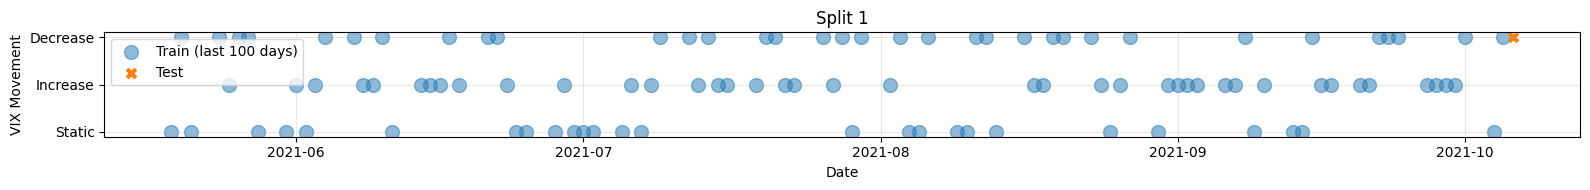

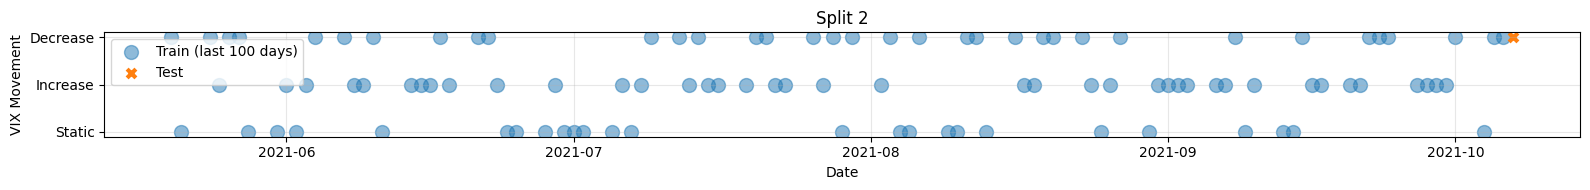

In [9]:
splits = walk_forward_expanding(data, initial_years=15,n_components=14,daily_window=500,)

for i, (X_train, X_test, y_train, y_test) in enumerate(splits[:3]):
    print(f"Split {i+1}")
    if X_test is None:
        print("Initial training only")
    else:
        print("Train size:", len(X_train), "/ Test size:", len(X_test))
        print("Train From:", X_train.index[0].date(), "to", X_train.index[-1].date())
        print("Test Date:", X_test.index[0].date())
    print("-" * 50)

last_n_days = 100

for i, (X_train, X_test, Y_train, Y_test) in enumerate(splits[1:3]):

    if X_test is None or Y_test is None:
        continue  # skip initial split

    Y_train_last = Y_train.iloc[-last_n_days:]
    Y_test_day = Y_test

    plt.figure(figsize=(16, 2))
    plt.scatter(Y_train_last.index, Y_train_last,
                label='Train (last 100 days)', s=100, alpha=0.5)
    plt.scatter(Y_test_day.index, Y_test_day,
                label='Test', s=40, marker='x', linewidths=3)

    plt.xlabel("Date")
    plt.ylabel("VIX Movement")
    plt.yticks([0, 1, 2], ['Static', 'Increase', 'Decrease'])
    plt.title(f"Split {i+1}")
    plt.legend(loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Model

In [10]:
# hyperparameters grid (including polynomial degree)
param_grid = {
    'poly__degree': [2],
    'logreg__C': [0.1, 1, 10, 50, 100],
    'logreg__penalty': ['l2'],
    'logreg__solver': ['lbfgs']
}


In [ ]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

# save results
scores = []
pred_real = pd.DataFrame()

# columns used for hmm
hmm_cols = ["PC1", "PC2", "PC3"]
scaler = StandardScaler()

# hyperparameters grid (including polynomial degree)
param_grid = {
    'poly__degree': [1, 2],
    'logreg__C': [35, 50, 75, 100],
    'logreg__penalty': ['l2'],
    'logreg__solver': ['lbfgs']
}

for i, (X_train, X_test, Y_train, Y_test) in enumerate(splits):
    if X_test is None or Y_test is None:
        continue  # skip splits without test

    # HMM regime detection
    X_train_hmm_scaled = scaler.fit_transform(X_train[hmm_cols])

    hmm = VariationalGaussianHMM(
        n_components=3,
        covariance_type="full",
        n_iter=1400,
        tol=1e-3,
        random_state=42,
        init_params="stmc",
        params="stmc"
    )
    hmm.fit(X_train_hmm_scaled)

    train_probs = hmm.predict_proba(X_train_hmm_scaled)
    X_test_hmm_scaled = scaler.transform(X_test[hmm_cols])
    test_probs = hmm.predict_proba(X_test_hmm_scaled)

    # add hmm probabilities to features
    X_train_copy = X_train.copy()
    X_test_copy = X_test.copy()

    for s in range(train_probs.shape[1]):
        X_train_copy[f"hmm_state_{s}"] = train_probs[:, s]
        X_test_copy[f"hmm_state_{s}"] = test_probs[:, s]

    # --- GRID SEARCH WITH PIPELINE ---
    pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000))])

    grid = GridSearchCV(pipeline, param_grid, scoring='precision_weighted', cv=2)
    grid.fit(X_train_copy, Y_train)
    best_model = grid.best_estimator_

    # Predictions
    preds_stack = best_model.predict(X_test_copy)

    # Save results
    pred_real = pd.concat([
        pred_real,
        pd.DataFrame({
            'pred_class': preds_stack,
            'real_class': Y_test.values.ravel(),
            'residual_class': Y_test.values.ravel() - preds_stack,
            'test_regime': hmm.predict(X_test_hmm_scaled)
        }, index=Y_test.index)
    ])

    # Save evaluations
    precision = precision_score(Y_test, preds_stack, zero_division=0, average="weighted")
    scores.append({
        'split': i + 1,
        'degree': grid.best_params_['poly__degree'],
        'C': grid.best_params_['logreg__C'],
        'precision_weighted': precision
    })

    print(f"Split {i+1}/{len(splits)} completed. Best degree: {grid.best_params_['poly__degree']}, Best C: {grid.best_params_['logreg__C']}")

# Final metrics
metrics_df = pd.DataFrame(scores)
precision_mean = round(metrics_df['precision_weighted'].mean(), 2)
print("Mean precision across models:", precision_mean)

In [12]:
scores_metrics=pd.DataFrame(scores)
mean_scores = scores_metrics.groupby(['C', 'degree'])['precision_weighted'].mean()
mean_scores

C    degree
35   1         0.418647
     2         0.404908
50   1         0.403509
     2         0.303797
75   1         0.307692
     2         0.402299
100  1         0.521739
     2         0.442029
Name: precision_weighted, dtype: float64

## Best Model

In [32]:
print("Best Model:",best_model[2],"|", best_model[0])

Best Model: LogisticRegression(C=35, max_iter=1000) | PolynomialFeatures(degree=1, include_bias=False)


In [ ]:
warnings.filterwarnings("ignore", category=UserWarning)

# Save results
pred_real = pd.DataFrame()

# Columns used for HMM
hmm_cols = ["PC1", "PC2", "PC3"]

# Fixed hyperparameters
model_lr=best_model

for i, (X_train, X_test, Y_train, Y_test) in enumerate(splits):
    if X_test is None or Y_test is None:
        continue  # skip splits without test

    # --- HMM regime detection ---
    X_train_hmm_scaled = scaler.fit_transform(X_train[hmm_cols])
    hmm = VariationalGaussianHMM(
        n_components=3,
        covariance_type="full",
        n_iter=1400,
        tol=1e-3,
        random_state=42,
        init_params="stmc",
        params="stmc"
    )
    hmm.fit(X_train_hmm_scaled)

    train_probs = hmm.predict_proba(X_train_hmm_scaled)
    X_test_hmm_scaled = scaler.transform(X_test[hmm_cols])
    test_probs = hmm.predict_proba(X_test_hmm_scaled)

    # Add HMM probabilities as features
    X_train_copy = X_train.copy()
    X_test_copy = X_test.copy()
    for s in range(train_probs.shape[1]):
        X_train_copy[f"hmm_state_{s}"] = train_probs[:, s]
        X_test_copy[f"hmm_state_{s}"] = test_probs[:, s]

    # Fit model
    model_lr.fit(X_train_copy, Y_train)

    # Predictions
    preds_stack = model_lr.predict(X_test_copy)

    # Save results
    pred_real = pd.concat([
        pred_real,
        pd.DataFrame({
            'pred_class': preds_stack,
            'real_class': Y_test.values.ravel(),
            'residual_class': Y_test.values.ravel() - preds_stack,
            'test_regime': hmm.predict(X_test_hmm_scaled)
        }, index=Y_test.index)
    ])

    # Optional: print split performance
    precision = precision_score(Y_test, preds_stack, zero_division=0, average="weighted")
    print(f"Split {i+1}/{len(splits)} completed. Precision: {precision:.4f}")

# Final metrics
precision_mean = round(precision_score(pred_real['real_class'], pred_real['pred_class'], average='weighted'), 4)
print("Mean precision across all splits:", precision_mean)


## Evaluate

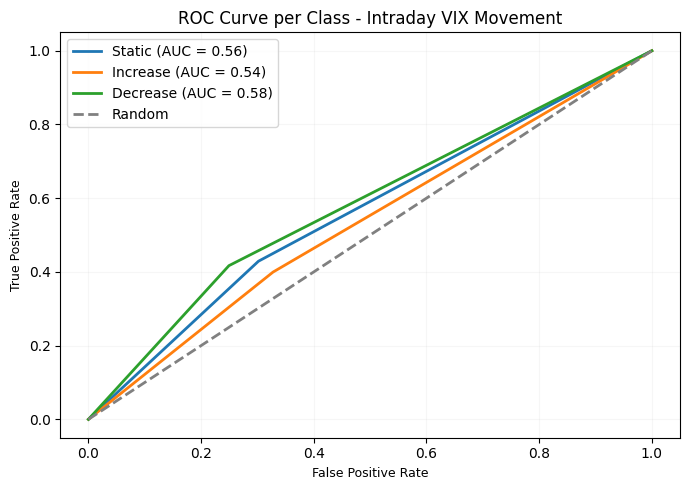

In [15]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# data
y_true = pred_real['real_class'].values
y_pred = pred_real['pred_class'].values
classes = [0, 1, 2]

# trasnform to binary results
y_true_bin = label_binarize(y_true, classes=classes)
y_pred_bin = label_binarize(y_pred, classes=classes)

labels = ['Static', 'Increase', 'Decrease']

plt.figure(figsize=(7, 5))

# roc curves per class
roc_aucs = []
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
    roc_auc = auc(fpr, tpr)
    roc_aucs.append(roc_auc)

    plt.plot(fpr, tpr, lw=2, label=f'{labels[i]} (AUC = {roc_auc:.2f})')

# random curve (0.5 per class, real 0.33 per class)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Random')

# labels and style
plt.xlabel('False Positive Rate', fontsize=9)
plt.ylabel('True Positive Rate', fontsize=9)
plt.title('ROC Curve per Class - Intraday VIX Movement', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(alpha=0.1)
plt.tight_layout()

plt.show()

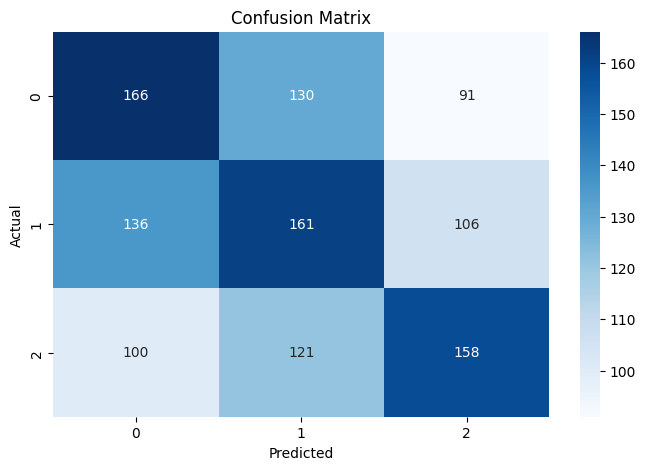

F1 Score:  0.42


In [16]:
cm = confusion_matrix(pred_real['real_class'], pred_real['pred_class'])
plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# F1 Score
f1 = f1_score(pred_real['real_class'], pred_real['pred_class'], average='macro')
print("F1 Score: ", round(f1, 2))

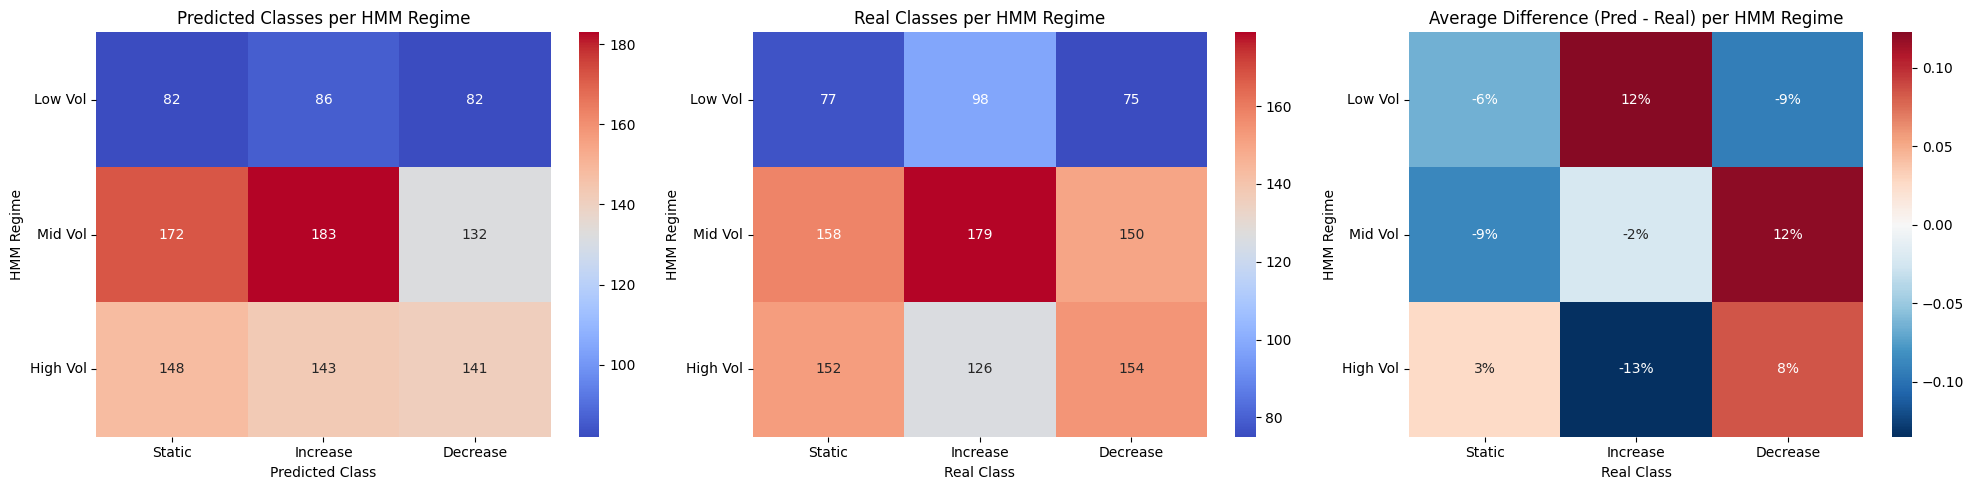

In [17]:
# Compute difference between predicted and real classes
pred_real['diff_class'] = pred_real['pred_class'] - pred_real['real_class']

# Pivot tables
heat_pred = pd.crosstab(pred_real['test_regime'], pred_real['pred_class'])
heat_real = pd.crosstab(pred_real['test_regime'], pred_real['real_class'])
heat_diff = (heat_real - heat_pred)/heat_real

# Create figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Heatmap of predictions
sns.heatmap(heat_pred, annot=True, fmt='d', cmap='coolwarm', ax=axes[0])
axes[0].set_xticks([0.5,1.5,2.5])
axes[0].set_xticklabels(["Static", "Increase", "Decrease"], rotation=0)
axes[0].set_yticks([0.5,1.5,2.5])
axes[0].set_yticklabels(['Low Vol','Mid Vol','High Vol'], rotation=0)
axes[0].set_title("Predicted Classes per HMM Regime")
axes[0].set_xlabel("Predicted Class")
axes[0].set_ylabel("HMM Regime")

# Heatmap of real classes
sns.heatmap(heat_real, annot=True, fmt='d', cmap='coolwarm', ax=axes[1])
axes[1].set_xticks([0.5,1.5,2.5])
axes[1].set_xticklabels(["Static", "Increase", "Decrease"], rotation=0)
axes[1].set_yticks([0.5,1.5,2.5])
axes[1].set_yticklabels(['Low Vol','Mid Vol','High Vol'], rotation=0)
axes[1].set_title("Real Classes per HMM Regime")
axes[1].set_xlabel("Real Class")
axes[1].set_ylabel("HMM Regime")

# Heatmap of differences (Predicted - Real)
sns.heatmap(heat_diff, annot=True, fmt=".0%", cmap='RdBu_r', center=0, ax=axes[2])
axes[2].set_xticks([0.5,1.5,2.5])
axes[2].set_xticklabels(["Static", "Increase", "Decrease"], rotation=0)
axes[2].set_yticks([0.5,1.5,2.5])
axes[2].set_yticklabels(['Low Vol','Mid Vol','High Vol'], rotation=0)
axes[2].set_title("Average Difference (Pred - Real) per HMM Regime")
axes[2].set_xlabel("Real Class")
axes[2].set_ylabel("HMM Regime")

plt.tight_layout()
plt.show()